# Hail → Solar · M0 → M1 — the event catalog

**Asset:** Hayhurst Texas Solar (EIA 66880) · **Peril:** Hail · **Layer:** M1 (event catalog)

This is the **M0→M1 seam**: turn the raw M0 evidence into a clean, reusable **hail event catalog** — one
canonical record per physical event, expressed as the interface object the rest of the pipeline consumes.
It is the object the old repo never built.

**The shape (decided in [`DD-1`](../../../docs/plans/hail/decisions.md); methodology in
[`learning_logs/01`](../../../docs/learning_logs/01_extending_a_short_hazard_record.md)):**

- **MRMS MESH (gridded) is the spine** — it supplies the **footprint** the seam requires. A20's rule: *a
  swath crosses the seam, never a bare point list.*
- **NOAA point reports are a cross-check / calibration overlay** — they validate the spine and set
  `confidence_flags`; **they do not add events** (the `HYBRID_VALIDATED` backbone, A20 §3.6).
- **Event = hail-day (v1)** — the MRMS product is a 24-h max, so a hail-day is the natural event unit
  (>95% of a day's severe reports fall in one ~4-h window). Sub-daily / connected-component splitting is
  deferred.
- **Interface = footprint raster bundle** (`RASTER_BUNDLE`); magnitude = **peak stone diameter (in)**.

This is **not** a symmetric merge, **not** per-event dedup, and `event_family_id` is **not** used to join
NOAA↔MRMS (that field is for cross-*peril* parent linkage). Plan: `docs/plans/hail/phase-2-event-catalog.md`.

## Assumptions (this layer)

**A6** one event = one hail-day · **A7** MRMS spine + NOAA cross-check (no events added) · **A8** frequency
= Negative Binomial *(**FITTED** on the ~5.65-yr record — over-dispersed → NegBin confirmed; DD-3)* · **A9**
dispersion prior (Fano φ ≈ 2, still informative at n=5) · **A10** footprint = union of above-threshold cells
(no smoothing). Full register: [assumptions A6–A10](../../../docs/plans/hail/assumptions.md#m1--event-catalog).

In [1]:
from __future__ import annotations
import os, gzip, json, math, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import box as shp_box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / ".env").exists() or (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")

ROOT = _repo_root()

# --- asset + region config (identical to M0 source 02, so the catalog is apples-to-apples) ---
ASSET = {"name": "Hayhurst Texas Solar", "eia_plant_id": 66880, "state": "TX", "county": "Culberson",
         "lat": 31.815992, "lon": -104.0853, "ac_capacity_mw": 24.8, "asset_value_usd": 36_778_400}
RADIUS_MI    = 50            # the region = a 50-mi circle around the asset (same as NOAA M0)
THRESHOLD_MM = 25.4          # 1 inch — NWS severe-hail definition (H10 catalog threshold)
WINDOW       = ("2020-10-15", "2026-06-08")   # FULL MRMS-on-AWS record (Stage-1 widening — DD-3)
PRODUCT      = "CONUS/MESH_Max_1440min_00.50"
RES_DEG, RES_M = 0.01, 1000  # MRMS native grid resolution
PX_KM2 = (RES_DEG * 111.32) * (RES_DEG * 111.32 * math.cos(math.radians(ASSET["lat"])))  # ~1.05 km²/pixel
GEOM_CRS, EQ_AREA = "EPSG:4326", "EPSG:5070"  # store geometry in lon/lat; measure area in Conus Albers (equal-area)

def box_from_radius(lat, lon, r_mi):
    dlat = r_mi / 69.0; dlon = r_mi / (69.0 * math.cos(math.radians(lat)))
    return {"lat_lo": lat - dlat, "lat_hi": lat + dlat, "lon_lo": lon - dlon, "lon_hi": lon + dlon}
BOX = box_from_radius(ASSET["lat"], ASSET["lon"], RADIUS_MI)

def region_mask(sub, lat0, lon0, r_mi):
    """2-D mask of grid cells within r_mi great-circle of the site — THE region (the 50-mi circle)."""
    LO, LA = np.meshgrid(sub.longitude.values, sub.latitude.values)
    lon180 = np.where(LO > 180, LO - 360, LO)
    R = 3958.8
    dphi = np.radians(LA - lat0); dl = np.radians(lon180 - lon0)
    a = np.sin(dphi / 2) ** 2 + np.cos(np.radians(lat0)) * np.cos(np.radians(LA)) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a)) <= r_mi

class MRMS:
    """Cache-first reader for the MRMS MESH tiles already pulled in M0 source 02 (no network on cache hit)."""
    def __init__(self, product, cache_dir):
        self.product = product
        self.cache = Path(cache_dir)
        self.mpath = self.cache / "_manifest.json"
        self.manifest = json.loads(self.mpath.read_text()) if self.mpath.exists() else {}

    def get_day(self, ymd):
        fn = self.manifest.get(ymd)
        return (self.cache / fn) if fn and (self.cache / fn).exists() else None

    @staticmethod
    def read_grid(gz_path):
        raw = gzip.decompress(Path(gz_path).read_bytes())
        with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tf:
            tf.write(raw); tmp = tf.name
        try:
            ds = xr.open_dataset(tmp, engine="cfgrib", backend_kwargs={"indexpath": ""})
            ds.load()
            return ds, ds[list(ds.data_vars)[0]]
        finally:
            os.unlink(tmp)

    @staticmethod
    def subset_box(da, box):
        la, lo = da.latitude.values, da.longitude.values
        lat_idx = np.where((la >= box["lat_lo"]) & (la <= box["lat_hi"]))[0]
        lon_idx = np.where((lo >= box["lon_lo"] % 360) & (lo <= box["lon_hi"] % 360))[0]
        sub = da.isel(latitude=lat_idx, longitude=lon_idx)
        arr = np.where(sub.values.astype("float64") < 0, np.nan, sub.values.astype("float64"))
        return sub, arr

mrms = MRMS(PRODUCT, ROOT / "data" / "hail" / "mrms_raw")
print(f"repo root: {ROOT}")
print(f"region: {RADIUS_MI}-mi circle @ ({ASSET['lat']}, {ASSET['lon']}) | threshold ≥ {THRESHOLD_MM} mm | window {WINDOW[0]}…{WINDOW[1]}")
print(f"MRMS cache: {mrms.cache} | cached tiles: {len(mrms.manifest)}")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
region: 50-mi circle @ (31.815992, -104.0853) | threshold ≥ 25.4 mm | window 2020-10-15…2026-06-08
MRMS cache: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/mrms_raw | cached tiles: 2063


## 1 · Load the M0 evidence

Two M0 sources, two roles. **MRMS** = the spine (hail-day proto-events *with footprints*). **NOAA** =
point reports for cross-check only; filtered to the catalog window so the validation is on the overlap.

In [2]:
# Wide M0 from the full-record scan (scripts/scan_mrms_record.py) — ALL days; hail-days are the events.
m0_all = pd.read_parquet(ROOT / "data/hail/hayhurst_hail_m0_mrms_202010_202606.parquet")
m0_all["date"] = pd.to_datetime(m0_all["date"])
m0_mrms = m0_all[m0_all.n_above_px > 0].copy()                      # hail-days = events
m0_mrms["event_id"] = "mrms_hail_" + m0_mrms.date.dt.strftime("%Y%m%d")
m0_mrms["peak_mesh_mm"] = m0_mrms["region_max_mm"]
noaa = pd.read_parquet(ROOT / "data/hail/hayhurst_hail_m0_noaa_50mi.parquet")
noaa["datetime"] = pd.to_datetime(noaa["datetime"], utc=True)
noaa_w = noaa[(noaa.datetime >= WINDOW[0]) & (noaa.datetime <= f"{WINDOW[1]} 23:59:59")].copy()
YRS = (m0_all.date.max() - m0_all.date.min()).days / 365.25         # record length (years)

print(f"MRMS record: {len(m0_all)} days scanned over {YRS:.2f} yr → {len(m0_mrms)} hail-day events")
print(f"NOAA total : {len(noaa)} point reports, {noaa.datetime.min().date()} → {noaa.datetime.max().date()}")
print(f"NOAA overlap with MRMS: {len(noaa_w)} reports in {WINDOW[0]}…{WINDOW[1]} (the cross-check window)")
m0_mrms.sort_values("date").reset_index(drop=True)

MRMS record: 2063 days scanned over 5.65 yr → 158 hail-day events
NOAA total : 373 point reports, 1996-06-14 → 2024-11-01
NOAA overlap with MRMS: 24 reports in 2020-10-15…2026-06-08 (the cross-check window)


,date,region_max_mm,n_above_px,footprint_km2,event_id,peak_mesh_mm
0,2020-12-06,49.599998,4,4.2,mrms_hail_20201206,49.599998
1,2021-04-27,34.400002,1,1.1,mrms_hail_20210427,34.400002
2,2021-05-15,69.500000,150,158.0,mrms_hail_20210515,69.500000
3,2021-05-21,29.200001,3,3.2,mrms_hail_20210521,29.200001
4,2021-05-22,41.799999,42,44.2,mrms_hail_20210522,41.799999
...,...,...,...,...,...,...
153,2026-06-03,40.599998,54,56.9,mrms_hail_20260603,40.599998
154,2026-06-04,40.400002,48,50.5,mrms_hail_20260604,40.400002
155,2026-06-05,38.099998,23,24.2,mrms_hail_20260605,38.099998
156,2026-06-06,31.900000,8,8.4,mrms_hail_20260606,31.900000


## 2 · The catalog contract — what M0→M1 emits

Per A20 §10 / §6.4 and A12 §10. A **complete-pass** field dictionary for the per-event `Event` record we
build below (the manifest is built in §6). Every field listed with its meaning, units, and source.

In [3]:
contract = pd.DataFrame([
    ("event_id",          "str",   "stable per-event id (mrms_hail_YYYYMMDD)",            "—",     "MRMS spine"),
    ("event_family_id",   "null",  "cross-PERIL parent link — null for standalone hail",  "—",     "kept for extensibility (A13 F7)"),
    ("catalog_id",        "str",   "backref to the CatalogManifest",                      "—",     "manifest"),
    ("peril",             "str",   "canonical peril (A12 row 2)",                         "—",     "HAIL"),
    ("ontology",          "str",   "event shape — footprint swath",                       "—",     "SWATH"),
    ("time_start_utc",    "ts",    "start of the 24-h accumulation window",               "UTC",   "valid_time − 24h"),
    ("time_end_utc",      "ts",    "end of the 24-h accumulation window",                 "UTC",   "= valid_time"),
    ("valid_time_utc",    "ts",    "the MESH tile's valid timestamp",                     "UTC",   "MRMS tile"),
    ("intensity_field_ref","str",  "→ the materialized footprint raster (cached tile)",   "path",  "MRMS raw cache"),
    ("geometry",          "geom",  "**footprint swath polygon** (Multi)Polygon — the real shape", "deg (EPSG:4326)", "vectorized MESH cells"),
    ("footprint_area_km2","float", "footprint area (equal-area) — the `F` for Minkowski",  "km²",   "from geometry (EPSG:5070)"),
    ("cell_count",        "int",   "# ≥threshold grid cells",                             "px",    "MRMS raster"),
    ("n_footprint_parts", "int",   "# disjoint swaths in-region that day",                "—",     "from geometry"),
    ("resolution_m",      "int",   "native grid resolution",                              "m",     "MRMS (~1 km)"),
    ("centroid_lon/lat",  "float", "footprint **polygon** centroid",                      "deg",   "from geometry"),
    ("bbox_min/max lon/lat","float","footprint bounding box",                             "deg",   "from geometry"),
    ("peak_intensity_mm", "float", "peak MESH in region that day",                        "mm",    "MRMS raster"),
    ("peak_intensity_in", "float", "peak stone diameter = mm ÷ 25.4 (A12 magnitude)",     "in",    "derived"),
    ("annual_rate",       "float", "1/years_in_record (each event: once in ~5.65 yr)",    "1/yr",  "fitted (§5)"),
    ("confidence_flags",  "json",  "NOAA cross-check outcome (backbone QA)",              "—",     "NOAA overlay (§4)"),
], columns=["field", "type", "what it is", "units", "source"])
contract

,field,type,what it is,units,source
0,event_id,str,stable per-event id (mrms_hail_YYYYMMDD),—,MRMS spine
1,event_family_id,null,cross-PERIL parent link — null for standalone ...,—,kept for extensibility (A13 F7)
2,catalog_id,str,backref to the CatalogManifest,—,manifest
3,peril,str,canonical peril (A12 row 2),—,HAIL
4,ontology,str,event shape — footprint swath,—,SWATH
5,time_start_utc,ts,start of the 24-h accumulation window,UTC,valid_time − 24h
6,time_end_utc,ts,end of the 24-h accumulation window,UTC,= valid_time
7,valid_time_utc,ts,the MESH tile's valid timestamp,UTC,MRMS tile
8,intensity_field_ref,str,→ the materialized footprint raster (cached tile),path,MRMS raw cache
9,geometry,geom,**footprint swath polygon** (Multi)Polygon — t...,deg (EPSG:4326),vectorized MESH cells


## 3 · Materialize the footprint bundles → canonical `Event` records

For each MRMS hail-day we re-open the cached raster, mask to the region + threshold, and **vectorize the
above-threshold cells into a real footprint polygon** (a shapely (Multi)Polygon, EPSG:4326) — the faithful
*footprint swath*, not just a point. The bundle's scalars are then derived **from that geometry** (A20
§6.4: `footprint_area_km2` via an equal-area projection, polygon `centroid`, `bbox`, plus `cell_count`,
`peak_intensity`, `valid_time`) — so the downstream Minkowski coupling can read `F`, *and* do a true
geometric overlap, without re-opening the raster. Disjoint storms in one day become a MultiPolygon
(`n_footprint_parts` > 1) — which also sets up future per-swath event splitting (H10).

In [4]:
def footprint_bundle(ymd: str) -> dict:
    gz = mrms.get_day(ymd)
    if gz is None:
        raise FileNotFoundError(f"no cached MRMS tile for {ymd}")
    sub, arr = mrms.subset_box(mrms.read_grid(gz)[1], BOX)
    arr = np.where(region_mask(sub, ASSET["lat"], ASSET["lon"], RADIUS_MI), arr, np.nan)  # → 50-mi circle
    above = np.isfinite(arr) & (arr >= THRESHOLD_MM)
    LO, LA = np.meshgrid(sub.longitude.values, sub.latitude.values)
    LO = np.where(LO > 180, LO - 360, LO)                      # 0–360 → −180…180 for EPSG:4326
    n = int(above.sum())
    peak_mm = float(np.nanmax(arr)) if np.isfinite(arr).any() else np.nan
    fn = mrms.manifest[ymd]
    valid = pd.to_datetime(fn.split("_")[-1].split(".")[0], format="%Y%m%d-%H%M%S", utc=True)

    # --- vectorize the above-threshold cells into a real footprint polygon ---
    # union of cell squares: adjacent cells dissolve into one swath; disjoint storms → a MultiPolygon
    # (which also gives us the connected components for free, for future per-swath event splitting).
    dx = float(abs(LO[0, 1] - LO[0, 0])); dy = float(abs(LA[1, 0] - LA[0, 0]))
    ys, xs = np.where(above)
    cells = [shp_box(LO[r, c] - dx / 2, LA[r, c] - dy / 2, LO[r, c] + dx / 2, LA[r, c] + dy / 2)
             for r, c in zip(ys, xs)]
    geom = unary_union(cells) if cells else None

    if geom is not None:
        area_km2 = round(float(gpd.GeoSeries([geom], crs=GEOM_CRS).to_crs(EQ_AREA).area.iloc[0]) / 1e6, 1)
        cen = geom.centroid
        cen_lon, cen_lat = round(cen.x, 4), round(cen.y, 4)
        minx, miny, maxx, maxy = [round(v, 4) for v in geom.bounds]
        n_parts = len(geom.geoms) if geom.geom_type == "MultiPolygon" else 1
    else:
        area_km2, cen_lon, cen_lat = 0.0, np.nan, np.nan
        minx = miny = maxx = maxy = np.nan; n_parts = 0

    return {
        "cell_count": n,
        "footprint_area_km2": area_km2,            # equal-area (EPSG:5070), from the geometry
        "n_footprint_parts": n_parts,              # # disjoint swaths in-region that day
        "resolution_m": RES_M,
        "centroid_lon": cen_lon, "centroid_lat": cen_lat,
        "bbox_minlon": minx, "bbox_minlat": miny, "bbox_maxlon": maxx, "bbox_maxlat": maxy,
        "peak_intensity_mm": round(peak_mm, 1),
        "peak_intensity_in": round(peak_mm / 25.4, 2),
        "valid_time_utc": valid,
        "time_end_utc": valid,
        "time_start_utc": valid - pd.Timedelta(hours=24),
        "intensity_field_ref": f"data/hail/mrms_raw/{fn}",
        "geometry": geom,                          # shapely (Multi)Polygon, EPSG:4326 — the footprint swath
    }

CATALOG_ID = f"hail_hayhurst_{RADIUS_MI}mi_v1"
rows = []
for _, r in m0_mrms.sort_values("date").iterrows():
    ymd = r["date"].strftime("%Y%m%d")
    b = footprint_bundle(ymd)
    rows.append({"event_id": r["event_id"], "event_family_id": None, "catalog_id": CATALOG_ID,
                 "peril": "HAIL", "ontology": "SWATH", **b, "annual_rate": round(1.0 / YRS, 4)})
events = gpd.GeoDataFrame(rows, geometry="geometry", crs=GEOM_CRS)

# sanity (1): cell count must match the M0 proto-event (same masking, same threshold).
# sanity (2): reconcile the new geometry area (equal-area EPSG:5070) vs M0's cos-lat pixel-count area —
#             they should agree to a few %; the geometry value is the geometrically correct one.
chk = events.merge(m0_mrms[["event_id", "footprint_km2", "n_above_px"]], on="event_id")
cells_match = bool((chk.cell_count == chk.n_above_px).all())
chk["area_diff_pct"] = (100 * (chk.footprint_area_km2 - chk.footprint_km2) / chk.footprint_km2).round(2)
print(f"{len(events)} canonical Event records (GeoDataFrame, CRS={events.crs.to_string()})")
print(f"cell_count matches M0 proto-events: {cells_match}")
print(f"geometry-area vs pixel-count area: {chk.area_diff_pct.min():+.2f}% … {chk.area_diff_pct.max():+.2f}% "
      f"(small ⇒ both consistent; geometry value is the correct one)")
print(f"geometry types: {events.geom_type.value_counts().to_dict()} | multi-part days: {(events.n_footprint_parts>1).sum()}")
events[["event_id", "valid_time_utc", "footprint_area_km2", "cell_count", "n_footprint_parts",
        "centroid_lon", "centroid_lat", "peak_intensity_in"]].head(12)

158 canonical Event records (GeoDataFrame, CRS=EPSG:4326)
cell_count matches M0 proto-events: True
geometry-area vs pixel-count area: -9.09% … +1.19% (small ⇒ both consistent; geometry value is the correct one)
geometry types: {'MultiPolygon': 129, 'Polygon': 29} | multi-part days: 129


,event_id,valid_time_utc,footprint_area_km2,cell_count,n_footprint_parts,centroid_lon,centroid_lat,peak_intensity_in
0,mrms_hail_20201206,2020-12-06 23:30:00+00:00,4.2,4,2,-103.9300,31.2100,1.95
1,mrms_hail_20210427,2021-04-27 23:30:00+00:00,1.0,1,1,-103.3950,32.1450,1.35
2,mrms_hail_20210515,2021-05-15 23:30:00+00:00,156.8,150,14,-104.3891,32.1937,2.74
3,mrms_hail_20210521,2021-05-21 23:30:00+00:00,3.1,3,1,-103.9683,32.1483,1.15
4,mrms_hail_20210522,2021-05-22 23:30:00+00:00,43.9,42,6,-104.3464,32.2836,1.65
5,mrms_hail_20210523,2021-05-23 23:30:00+00:00,3.2,3,2,-104.1317,31.3750,1.09
6,mrms_hail_20210524,2021-05-24 23:30:00+00:00,94.5,90,29,-104.2594,31.7844,1.53
7,mrms_hail_20210525,2021-05-25 23:30:00+00:00,95.7,91,20,-104.0780,31.6963,2.08
8,mrms_hail_20210526,2021-05-26 23:30:00+00:00,34.5,33,10,-103.4456,32.1056,1.45
9,mrms_hail_20210527,2021-05-27 23:30:00+00:00,1.0,1,1,-104.2850,32.1050,1.01


## 4 · NOAA cross-check — the calibration overlay

NOAA reports do **not** add events. They *validate the spine*: for each MRMS hail-day we look for a NOAA
report in-region within **±1 day**, write the outcome into `confidence_flags`, and report the **undercount**
(MRMS hail-days vs days NOAA actually reported) and a **MESH-vs-report size** sanity check. MESH is an
over-forecast by design (~75% of observed hail falls below it — [`learning_logs/01`](../../../docs/learning_logs/01_extending_a_short_hazard_record.md)),
so on matched days we expect peak MESH (in) ≳ the reported stone size.

In [5]:
noaa_days = pd.to_datetime(noaa_w.datetime.dt.date.unique())
conf, matched_pairs = [], []
for _, e in events.iterrows():
    d = e["valid_time_utc"].normalize().tz_localize(None)
    hits = noaa_w[(noaa_w.datetime.dt.tz_localize(None) >= d - pd.Timedelta(days=1)) &
                  (noaa_w.datetime.dt.tz_localize(None) <= d + pd.Timedelta(days=1))]
    flag = {"noaa_report_within_1d": bool(len(hits)), "n_noaa_matched": int(len(hits)),
            "noaa_max_size_in": (round(float(hits.intensity_in.max()), 2) if len(hits) else None),
            "radar_backbone": "MRMS_MESH_1440min"}
    conf.append(json.dumps(flag))
    if len(hits):
        matched_pairs.append({"event_id": e["event_id"], "date": d, "mrms_peak_in": e["peak_intensity_in"],
                              "noaa_max_in": round(float(hits.intensity_in.max()), 2), "n_noaa": int(len(hits))})
events["confidence_flags"] = conf

n_mrms = len(events)
n_mrms_with_noaa = sum(json.loads(c)["noaa_report_within_1d"] for c in conf)
n_noaa_days = len(noaa_days)
undercount = n_mrms / max(n_noaa_days, 1)
print(f"MRMS hail-days in window     : {n_mrms}")
print(f"NOAA-reported days in window : {n_noaa_days}  ({len(noaa_w)} reports)")
print(f"MRMS days w/ a NOAA report   : {n_mrms_with_noaa}  →  {n_mrms - n_mrms_with_noaa} MRMS days NOAA never reported")
print(f"≈ undercount ratio (MRMS days / NOAA days): {undercount:.1f}×  "
      f"(literature ≈ 5–6× regionally; tiny-sample here — see learning_logs/01)")
pd.DataFrame(matched_pairs) if matched_pairs else "no NOAA reports matched any MRMS event-day in this window"

MRMS hail-days in window     : 158
NOAA-reported days in window : 11  (24 reports)
MRMS days w/ a NOAA report   : 16  →  142 MRMS days NOAA never reported
≈ undercount ratio (MRMS days / NOAA days): 14.4×  (literature ≈ 5–6× regionally; tiny-sample here — see learning_logs/01)


,event_id,date,mrms_peak_in,noaa_max_in,n_noaa
0,mrms_hail_20210528,2021-05-28,1.27,2.50,7
1,mrms_hail_20210529,2021-05-29,2.62,2.50,7
2,mrms_hail_20220603,2022-06-03,1.91,2.00,2
3,mrms_hail_20220604,2022-06-04,2.81,2.00,2
4,mrms_hail_20220722,2022-07-22,1.53,1.00,1
5,mrms_hail_20230528,2023-05-28,1.46,1.00,1
6,mrms_hail_20230701,2023-07-01,2.23,1.25,1
7,mrms_hail_20231002,2023-10-02,2.75,2.75,4
8,mrms_hail_20231003,2023-10-03,2.70,2.75,4
9,mrms_hail_20231024,2023-10-24,1.59,1.00,1


**Timeline — the spine vs the overlay.** MRMS hail-days (stems, height = peak hail size in) and NOAA
reports (markers). The gap between them *is* the population undercount: MRMS sees hail the ground network
didn't report.

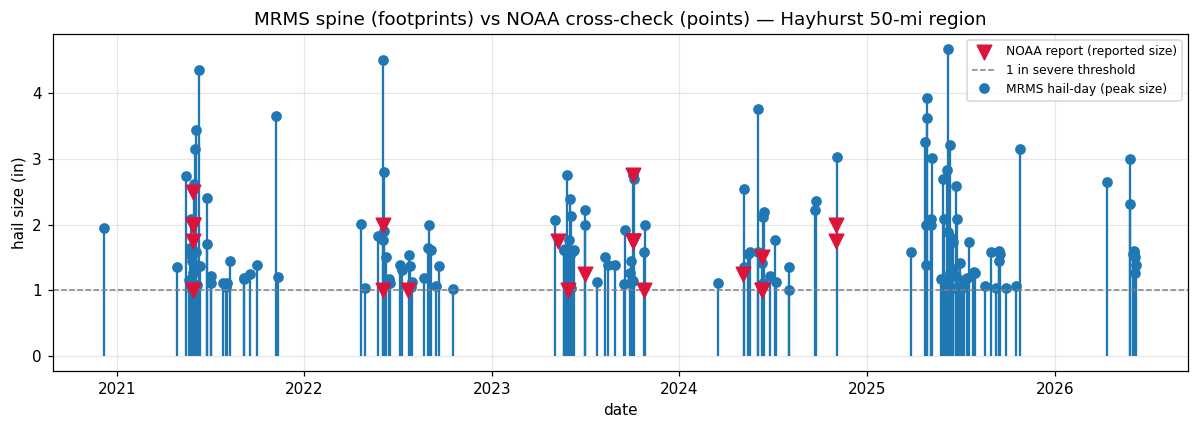

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.stem(events["valid_time_utc"].dt.tz_localize(None), events["peak_intensity_in"],
        linefmt="C0-", markerfmt="C0o", basefmt=" ", label="MRMS hail-day (peak size)")
if len(noaa_w):
    ax.scatter(noaa_w.datetime.dt.tz_localize(None), noaa_w.intensity_in, marker="v", s=90,
               color="crimson", zorder=5, label="NOAA report (reported size)")
ax.axhline(THRESHOLD_MM / 25.4, color="gray", ls="--", lw=1, label=f"{THRESHOLD_MM/25.4:.0f} in severe threshold")
ax.set(title="MRMS spine (footprints) vs NOAA cross-check (points) — Hayhurst 50-mi region",
       xlabel="date", ylabel="hail size (in)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5 · Frequency — **fitted** on the widened record  (the Stage-1 payoff — DD-2 / DD-3)

With the **full ~5.65-yr MRMS record** we can finally fit `λ_collection` and **test the over-dispersion**
(the NegBin call from DD-2). We count hail-days per **full** calendar year (2020 & 2026 are partial →
excluded from the rate), then compare the variance of those annual counts to their mean — the **Fano
factor** `φ`. `φ ≈ 1` → Poisson; `φ > 1` → over-dispersed → Negative Binomial. *Honest caveat:* 5 full
years is still few (A24 §4.3 flags the test underpowered < 10–15 yr) — **decent, not ideal**; the prior
(φ ≈ 2) still informs, and the NOAA-calibrated extension (DD-3 Stage 2) is the path to a longer record.

hail-days per calendar year: {2020: 1, 2021: 32, 2022: 23, 2023: 29, 2024: 19, 2025: 45, 2026: 9}
λ_collection (full-year mean) = 29.6/yr   [total 158 days / 5.65 yr = 28.0/yr]
Fano factor φ = var/mean = 99.8/29.6 = 3.37  →  OVER-DISPERSED → Negative Binomial  (NegBin Gamma shape k ≈ 12.5)
⚠ n=5 full years — underpowered (A24); decent, not ideal. Prior φ≈2; DD-3 Stage 2 = NOAA-calibrated extension.


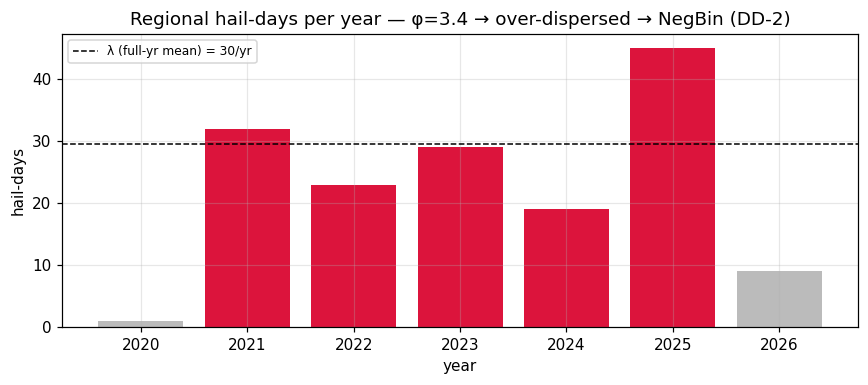

(grey = partial years 2020/2026, excluded from the rate; crimson = full years used for λ + dispersion)


In [7]:
m0_all["year"] = m0_all.date.dt.year
hail_by_year = m0_all[m0_all.n_above_px > 0].groupby("year").size()
FULL_YEARS = [2021, 2022, 2023, 2024, 2025]                          # complete calendar years in the record
counts = hail_by_year.reindex(range(int(m0_all.year.min()), int(m0_all.year.max()) + 1), fill_value=0)
full = counts.loc[FULL_YEARS]
lam_collection = float(full.mean())                                 # full-year mean hail-days/yr
fano = float(full.var(ddof=1) / full.mean())                        # variance-to-mean (φ)
k_negbin = lam_collection / (fano - 1) if fano > 1 else float("inf")  # Gamma shape (NegBin); →∞ ≡ Poisson
print("hail-days per calendar year:", {int(y): int(c) for y, c in counts.items()})
print(f"λ_collection (full-year mean) = {lam_collection:.1f}/yr   [total {int(counts.sum())} days / {YRS:.2f} yr = {counts.sum()/YRS:.1f}/yr]")
print(f"Fano factor φ = var/mean = {full.var(ddof=1):.1f}/{full.mean():.1f} = {fano:.2f}  →  "
      f"{'OVER-DISPERSED → Negative Binomial' if fano > 1.2 else 'Poisson-like'}  (NegBin Gamma shape k ≈ {k_negbin:.1f})")
print(f"⚠ n={len(FULL_YEARS)} full years — underpowered (A24); decent, not ideal. Prior φ≈2; DD-3 Stage 2 = NOAA-calibrated extension.")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(counts.index.astype(str), counts.values,
       color=["crimson" if y in FULL_YEARS else "#bbb" for y in counts.index])
ax.axhline(lam_collection, color="black", ls="--", lw=1, label=f"λ (full-yr mean) = {lam_collection:.0f}/yr")
ax.set(title=f"Regional hail-days per year — φ={fano:.1f} → over-dispersed → NegBin (DD-2)", xlabel="year", ylabel="hail-days")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("(grey = partial years 2020/2026, excluded from the rate; crimson = full years used for λ + dispersion)")

## 6 · Event-footprint map + the `CatalogManifest`

The **real footprint swaths** (polygons, colored by peak hail size) in the region — the actual shapes the
catalog now carries, not just points. Then the self-describing manifest that declares all five choices.

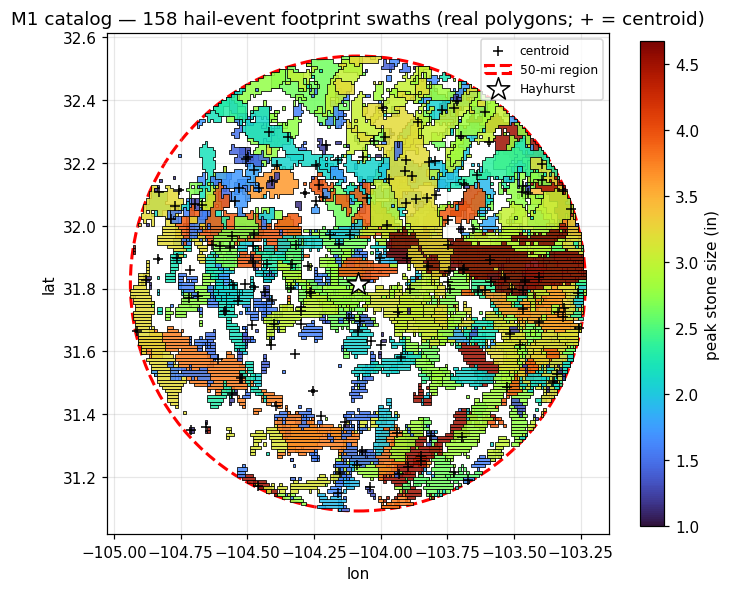

In [8]:
dlat = RADIUS_MI / 69.0; dlon = RADIUS_MI / (69.0 * math.cos(math.radians(ASSET["lat"])))
fig, ax = plt.subplots(figsize=(6.6, 6.6))
events.plot(ax=ax, column="peak_intensity_in", cmap="turbo", edgecolor="k", linewidth=0.6, alpha=0.85,
            legend=True, legend_kwds={"label": "peak stone size (in)", "shrink": 0.7}, zorder=4)
ax.scatter(events.centroid_lon, events.centroid_lat, marker="+", s=45, color="black", lw=1, zorder=5, label="centroid")
ax.add_patch(Ellipse((ASSET["lon"], ASSET["lat"]), width=2*dlon, height=2*dlat,
                     fill=False, ec="red", ls="--", lw=2, label=f"{RADIUS_MI}-mi region"))
ax.scatter([ASSET["lon"]], [ASSET["lat"]], marker="*", s=240, color="white", edgecolor="black", zorder=6, label="Hayhurst")
ax.set(title=f"M1 catalog — {len(events)} hail-event footprint swaths (real polygons; + = centroid)",
       xlabel="lon", ylabel="lat"); ax.legend(loc="upper right", fontsize=8)
ax.set_aspect(1/math.cos(math.radians(ASSET["lat"]))); plt.tight_layout(); plt.show()

In [9]:
manifest = {
    "catalog_id": CATALOG_ID,
    "peril": "HAIL",
    "asset": {"name": ASSET["name"], "eia_plant_id": ASSET["eia_plant_id"], "lat": ASSET["lat"], "lon": ASSET["lon"]},
    "event_ontology": "SWATH",
    "historical_backbone": "HYBRID_VALIDATED",   # MRMS gridded spine + NOAA point cross-check (A20 §3.6)
    "stochastic_method": "NONE",                 # V1: historical only
    "forward_looking": "NONE",                   # V1: current climate
    "interface_object": "RASTER_BUNDLE",
    "magnitude_metric": {"name": "peak_stone_diameter", "units": "in", "from": "MESH_mm / 25.4"},
    "footprint_geometry": {"present": True, "type": "(Multi)Polygon swath", "crs": GEOM_CRS,
                           "area_crs": EQ_AREA, "derived_from": "above-threshold MESH cells, unioned",
                           "formats": ["GeoParquet (geometry column)", "GeoJSON export"]},
    "spatial_resolution_m": RES_M,
    "temporal_resolution": "daily_24h_max (MESH_Max_1440min)",
    "climate_baseline": "current (historical, no adjustment)",
    "coverage_geometry": {"type": "circle", "center_lat": ASSET["lat"], "center_lon": ASSET["lon"], "radius_mi": RADIUS_MI},
    "coverage_temporal": {"start": WINDOW[0], "end": WINDOW[1], "note": f"full MRMS-on-AWS record (~{YRS:.1f} yr; Stage-1 widening, DD-3)"},
    "threshold_mm": THRESHOLD_MM,
    "frequency_process": "negative_binomial",   # over-dispersion CONFIRMED on the widened record — DD-2/DD-3
    "frequency_process_params": {
        "status": f"fitted (Stage 1 — full ~{YRS:.1f}-yr MRMS record; DD-3)",
        "lambda_collection_per_yr": round(lam_collection, 1),
        "annual_counts": {int(y): int(c) for y, c in counts.items()},
        "full_years_used": FULL_YEARS,
        "fano_factor": round(fano, 2),
        "dispersion": "over-dispersed (φ>1) → Negative Binomial confirmed over Poisson",
        "negbin_gamma_shape_k": round(k_negbin, 1),
        "caveat": f"n={len(FULL_YEARS)} full years — A24 flags the dispersion test underpowered <10-15yr; decent, not ideal",
        "prior": {"on": "annual-count Fano φ", "phi_median": 2.0, "phi_90ci": [1.0, 3.5],
                  "basis": "SCS VMR ≈ 1.5–3 (A24); still informative at small n"},
        "next": "NOAA-calibrated extension for a longer record (DD-3 Stage 2)",
        "ref": "DD-2, DD-3, learning_logs/02"},
    "sources": {
        "spine": {"name": "MRMS MESH", "product": PRODUCT, "bucket": "s3://noaa-mrms-pds", "role": "event footprints + intensity"},
        "cross_check": {"name": "NOAA Storm Events", "via": "Hydronos API", "role": "calibration/validation only — adds no events"},
    },
    "provenance": {"decision": "docs/plans/hail/decisions.md (DD-1 spine, DD-3 frequency)",
                   "methodology": "docs/learning_logs/01_extending_a_short_hazard_record.md",
                   "built_utc": pd.Timestamp.utcnow().isoformat()},
    "n_events": int(len(events)),
}
print(json.dumps(manifest, indent=2))

{
  "catalog_id": "hail_hayhurst_50mi_v1",
  "peril": "HAIL",
  "asset": {
    "name": "Hayhurst Texas Solar",
    "eia_plant_id": 66880,
    "lat": 31.815992,
    "lon": -104.0853
  },
  "event_ontology": "SWATH",
  "historical_backbone": "HYBRID_VALIDATED",
  "stochastic_method": "NONE",
  "forward_looking": "NONE",
  "interface_object": "RASTER_BUNDLE",
  "magnitude_metric": {
    "name": "peak_stone_diameter",
    "units": "in",
    "from": "MESH_mm / 25.4"
  },
  "footprint_geometry": {
    "present": true,
    "type": "(Multi)Polygon swath",
    "crs": "EPSG:4326",
    "area_crs": "EPSG:5070",
    "derived_from": "above-threshold MESH cells, unioned",
    "formats": [
      "GeoParquet (geometry column)",
      "GeoJSON export"
    ]
  },
  "spatial_resolution_m": 1000,
  "temporal_resolution": "daily_24h_max (MESH_Max_1440min)",
  "climate_baseline": "current (historical, no adjustment)",
  "coverage_geometry": {
    "type": "circle",
    "center_lat": 31.815992,
    "center_lon

/var/folders/lx/kqndjxl102vfy6qz_bd4qycc0000gn/T/ipykernel_69179/742628015.py:40: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "built_utc": pd.Timestamp.utcnow().isoformat()},


## 7 · Persist the M1 artifacts → `data/hail/`

The clean event catalog (parquet) + the self-describing manifest (JSON). These are what M1→M2 (coupling)
reads — no notebook re-execution required downstream.

In [10]:
out = ROOT / "data" / "hail"
cat_path = out / "hayhurst_hail_m1_catalog.parquet"          # GeoParquet (geometry column + CRS)
geojson_path = out / "hayhurst_hail_m1_catalog.geojson"      # portable export (QGIS / web maps)
man_path = out / "hayhurst_hail_m1_manifest.json"
cols = ["event_id", "event_family_id", "catalog_id", "peril", "ontology",
        "time_start_utc", "time_end_utc", "valid_time_utc", "intensity_field_ref",
        "footprint_area_km2", "cell_count", "n_footprint_parts", "resolution_m",
        "centroid_lon", "centroid_lat", "bbox_minlon", "bbox_minlat", "bbox_maxlon", "bbox_maxlat",
        "peak_intensity_mm", "peak_intensity_in", "annual_rate", "confidence_flags", "geometry"]
gdf = events[cols].reset_index(drop=True)
gdf.to_parquet(cat_path)                                     # geopandas → GeoParquet (WKB geometry + CRS metadata)
gj = gdf.copy()
for c in ["time_start_utc", "time_end_utc", "valid_time_utc"]:
    gj[c] = gj[c].astype(str)                                # GeoJSON drivers want string timestamps
gj.to_file(geojson_path, driver="GeoJSON")
man_path.write_text(json.dumps(manifest, indent=2))
print(f"M1 catalog  : {len(gdf)} events → {cat_path}  (GeoParquet, CRS={gdf.crs.to_string()})")
print(f"M1 geojson  :               → {geojson_path}")
print(f"M1 manifest :               → {man_path}")
gdf[["event_id", "footprint_area_km2", "n_footprint_parts", "centroid_lon", "centroid_lat", "peak_intensity_in"]].head()

M1 catalog  : 158 events → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m1_catalog.parquet  (GeoParquet, CRS=EPSG:4326)
M1 geojson  :               → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m1_catalog.geojson
M1 manifest :               → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m1_manifest.json


,event_id,footprint_area_km2,n_footprint_parts,centroid_lon,centroid_lat,peak_intensity_in
0,mrms_hail_20201206,4.2,2,-103.9300,31.2100,1.95
1,mrms_hail_20210427,1.0,1,-103.3950,32.1450,1.35
2,mrms_hail_20210515,156.8,14,-104.3891,32.1937,2.74
3,mrms_hail_20210521,3.1,1,-103.9683,32.1483,1.15
4,mrms_hail_20210522,43.9,6,-104.3464,32.2836,1.65


## Findings & carried-forward

- **The catalog exists.** M0 evidence → one canonical hail event per hail-day, each a **footprint swath
  polygon** (GeoParquet + GeoJSON) plus its scalars: `footprint_area_km2` (the `F` Minkowski needs),
  `peak_intensity_in` (conditional severity), polygon centroid, bbox, and a ref back to the raw raster.
  One record per physical event — *no event stored twice*.
- **MRMS spine + NOAA cross-check works as intended.** NOAA validated the spine and exposed the
  population **undercount** directly (MRMS saw more hail-days than NOAA reported) — exactly the bias
  `learning_logs/01` says to expect; recorded per-event in `confidence_flags`, with **no NOAA event added**.
- **Frequency FITTED (Stage 1):** `λ_collection` fitted on the full ~5.65-yr record; annual counts are
  **over-dispersed (Fano > 1) → NegBin confirmed** (DD-2). Still few full years (decent, not ideal — the
  NOAA-calibrated extension, [DD-3](../../../docs/plans/hail/decisions.md) Stage 2, is the path to a longer record).
- **Still deferred:** `event = hail-day` (sub-daily / connected-component swath-splitting); the long-record
  calibrated-splice / gridded-extension ([`learning_logs/01`](../../../docs/learning_logs/01_extending_a_short_hazard_record.md)).
- **Next — M1 → M2 (coupling):** feed each event's `footprint_area_km2` into the Minkowski hit-probability
  `p = (√F + √s)² / A` and `λ_asset = λ_collection · p`, against the Hayhurst plant footprint — *or*, now
  that each event carries a real polygon, a **true geometric overlap** of footprint ∩ asset-footprint
  (strictly more robust than areal `F`). The geometry keeps both paths open (A21; `hazard_math/01`).